<a href="https://colab.research.google.com/github/Swag-Pseudopy/LLMs-Flow-matching-and-more/blob/main/ToT_Linear_Eqn_Solver.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Available examples:
1) Example: 2x + 6 = 13.6
2) Example: 3x + 5 = 5.666666666666667
3) Example: 2x + 0 = 4
4) Example: 5x + -10 = 15

Choose one:
  - Enter 1/2/3/4 for an example
  - OR type 'custom'

Your choice: 4

Starting equation:
5x + -10 = 15

Choose search strategy (bfs / dfs): bfs

Expanding state: 5x + -10 = 15
Proposing next steps for: 5x + -10 = 15

LLM proposals:
5x = 25
5x + 0 = 15 + 10
5x - 0 = 15 + 10

Expanding state: 5x = 25
Proposing next steps for: 5x = 25

LLM proposals:
1. 5x = 25
2. 5x / 5 = 25 / 5
3. x = 5

Expanding state: 5x + 0 = 15 + 10
Proposing next steps for: 5x + 0 = 15 + 10

LLM proposals:
1. 5x = 25
2. 5x = 25
3. x = 5

Expanding state: 1. 5x = 25
Proposing next steps for: 1. 5x = 25

LLM proposals:
1. 5x = 25
2. x = 25 / 5
3. x = 5

Expanding state: 2. 5x / 5 = 25 / 5
Proposing next steps for: 2. 5x / 5 = 25 / 5

LLM proposals:
1. 5x = 25
2. x = 5
3. x = 25/5


Solution steps:

5x = 25
1. 5x = 25
2. x = 25 / 5

Nodes explored: 16


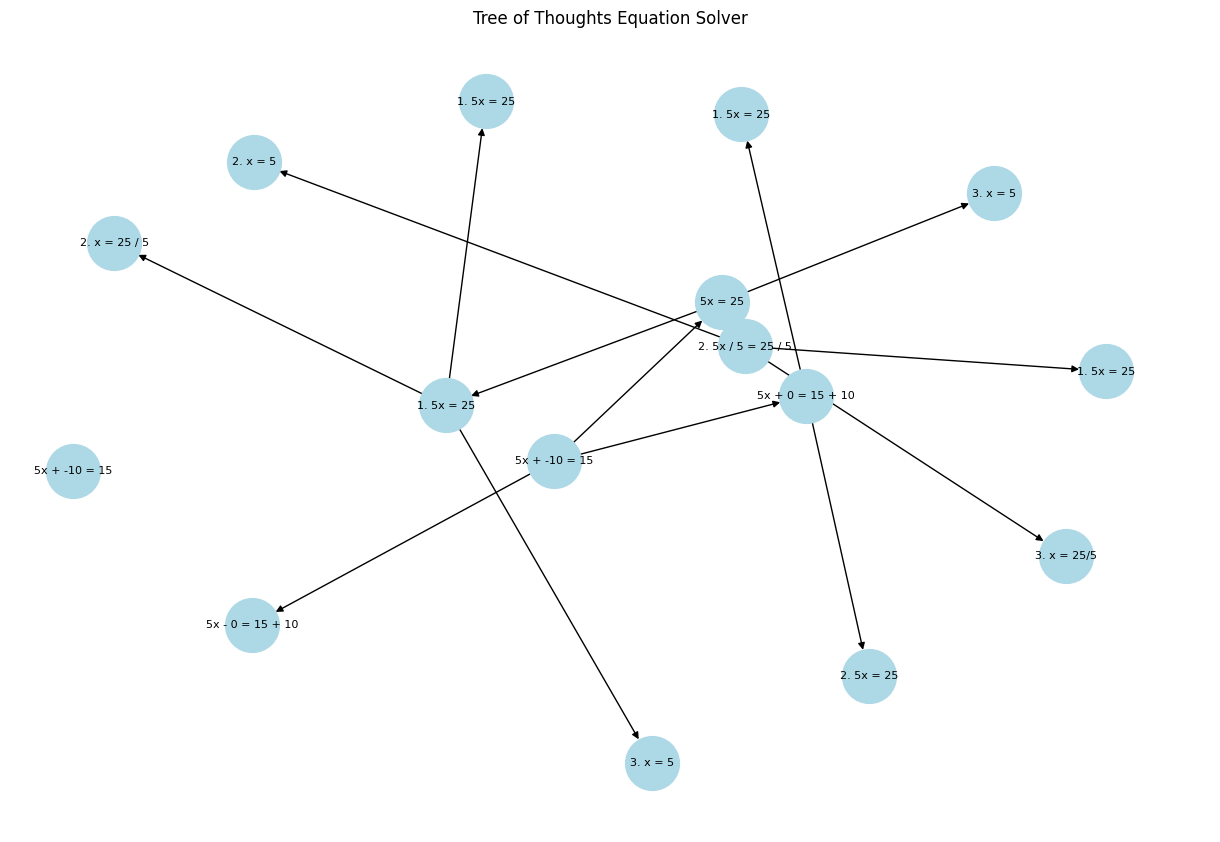

In [4]:
!pip -q install groq networkx matplotlib

import re
import networkx as nx
import matplotlib.pyplot as plt
from dataclasses import dataclass, field

# -------------------------
# Load GROQ key
# -------------------------

try:
    from google.colab import userdata
    GROQ_KEY = userdata.get("GROQ_API_KEY")
except:
    GROQ_KEY=None

from groq import Groq
client = Groq(api_key=GROQ_KEY)

# -------------------------
# CONFIG
# -------------------------

TEMPERATURE = 0
T = 3
B = 2
K = 3     # 5
VALUE_SAMPLES = 1     # 2
VALUE_THRESHOLD = 0.5

MODEL_CANDIDATES = [
"llama-3.3-70b-versatile",
"llama-3.1-8b-instant",
"mixtral-8x7b-32768",
"gemma2-9b-it"
]

# -------------------------
# Tree tracking
# -------------------------

SEARCH_TREE = nx.DiGraph()
NODE_COUNTER = 0

# -------------------------
# State
# -------------------------

@dataclass
class State:

    eq: str
    steps: list = field(default_factory=list)

    node_id: int = -1
    parent_id: int = -1


# -------------------------
# Register node
# -------------------------

def register_node(state,depth):

    global NODE_COUNTER

    NODE_COUNTER+=1
    state.node_id=NODE_COUNTER

    SEARCH_TREE.add_node(
        state.node_id,
        eq=state.eq,
        depth=depth
    )

    if state.parent_id!=-1:
        SEARCH_TREE.add_edge(state.parent_id,state.node_id)

# -------------------------
# Groq chat
# -------------------------

def groq_chat(prompt):

    for m in MODEL_CANDIDATES:
        try:

            r = client.chat.completions.create(
                model=m,
                messages=[{"role":"user","content":prompt}],
                temperature=TEMPERATURE
            )

            return r.choices[0].message.content.strip()

        except:
            continue

    raise RuntimeError("All models failed")

# -------------------------
# Prompts
# -------------------------

PROPOSE_EXAMPLE = """
Examples

2x + 6 = 13.6
x + 3 = 6.8
x = 3.8

3x + 5 = 17/3
3x = 2/3
x = 2/9

2x = 4
x = 2
"""

VALUE_EXAMPLE = """
Evaluate algebraic transitions

2x + 6 = 13.6
x + 3 = 6.8
sure

x + 3 = 6.8
x = 4
impossible
"""

def propose_prompt(eq,k):

    return f"""
You are solving a linear equation step by step.

{PROPOSE_EXAMPLE}

Current equation:
{eq}

Propose {k} valid next algebra steps.

Return only equations.
"""

def value_prompt(prev,next_eq):

    return f"""
{VALUE_EXAMPLE}

Evaluate transition:

{prev}
{next_eq}

Answer: sure or impossible
"""

# -------------------------
# Validation
# -------------------------

def validate_step(prev_eq,next_eq):

    if "=" not in next_eq:
        return False

    if "x" not in next_eq:
        return False

    return True

# -------------------------
# Scoring
# -------------------------

def score_label(l):

    l=l.lower()

    if "sure" in l:
        return 2

    if "impossible" in l:
        return 0

    return 1


def evaluate(prev,next_eq):

    total=0

    for _ in range(VALUE_SAMPLES):

        r = groq_chat(value_prompt(prev,next_eq))

        total+=score_label(r)

    return total/VALUE_SAMPLES

# -------------------------
# Goal check
# -------------------------

def clean_equation(eq):

    # remove numbering like "1. ", "2. "
    eq = re.sub(r"^\d+\.\s*", "", eq)

    return eq.strip()

def is_goal(eq):

    eq = clean_equation(eq)

    return re.match(r"x\s*=",eq)

# -------------------------
# Expansion
# -------------------------

def expand(state):

    print("Proposing next steps for:", state.eq)

    raw = groq_chat(propose_prompt(state.eq,K))
    print("\nLLM proposals:")
    print(raw)

    lines = [l.strip() for l in raw.split("\n") if l.strip()]

    children=[]

    for l in lines:

        if validate_step(state.eq,l):

            child = State(l,state.steps+[l])
            child.parent_id=state.node_id

            children.append(child)

    return children

# -------------------------
# DFS
# -------------------------

def dfs(state,depth):

    if is_goal(state.eq):
        return state

    if depth>T:
        return None

    print("\nDFS depth",depth)
    print("State:",state.eq)

    children = expand(state)

    scored=[]

    for c in children:

        score = evaluate(state.eq,c.eq)

        print("Candidate:",c.eq,"score",score)

        if score>VALUE_THRESHOLD:

            register_node(c,depth)

            scored.append((score,c))

    scored.sort(key=lambda x:x[0],reverse=True)

    for _,child in scored:

        r = dfs(child,depth+1)

        if r:
            return r

    return None

# -------------------------
# BFS
# -------------------------

def bfs(start):

    frontier=[start]

    register_node(start,0)

    for depth in range(1,T+1):

        candidates=[]

        for st in frontier:
            print("\nExpanding state:", st.eq)
            children=expand(st)

            for c in children:

                score = evaluate(st.eq,c.eq)

                if score>VALUE_THRESHOLD:

                    register_node(c,depth)

                    candidates.append((score,c))

        candidates.sort(reverse=True,key=lambda x:x[0])

        frontier=[c for _,c in candidates[:B]]

        for st in frontier:

            if is_goal(st.eq):
                return st

    return None

# -------------------------
# RUN
# -------------------------

EXAMPLES = {
    "1) Example": (2, 6, 13.6),     # x = 3.8
    "2) Example": (3, 5, 17/3),     # x = 2/9
    "3) Example": (2, 0, 4),        # x = 2
    "4) Example": (5, -10, 15),     # x = 5
}

print("Available examples:")
for name,(a,b,c) in EXAMPLES.items():
    print(f"{name}: {a}x + {b} = {c}")

print("\nChoose one:")
print("  - Enter 1/2/3/4 for an example")
print("  - OR type 'custom'")

choice = input("\nYour choice: ").strip().lower()

if choice == "custom":

    from fractions import Fraction

    a = Fraction(input("Enter a: "))
    b = Fraction(input("Enter b: "))
    c = Fraction(input("Enter c: "))

else:

    idx = int(choice)

    if idx not in [1,2,3,4]:
        raise ValueError("Invalid choice")

    a,b,c = list(EXAMPLES.values())[idx-1]

eq = f"{a}x + {b} = {c}"

print("\nStarting equation:")
print(eq)

strategy = input("\nChoose search strategy (bfs / dfs): ").strip().lower()

root = State(eq)

register_node(root,0)

if strategy == "dfs":
    solution = dfs(root,1)
else:
    solution = bfs(root)

print("\n================")

if solution:

    print("\nSolution steps:\n")

    for s in solution.steps:
        print(s)

else:
    print("No solution found")

print("\nNodes explored:", NODE_COUNTER)

# -------------------------
# Plot tree
# -------------------------

plt.figure(figsize=(12,8))

pos = nx.spring_layout(SEARCH_TREE)

labels = nx.get_node_attributes(SEARCH_TREE,"eq")

nx.draw(
    SEARCH_TREE,
    pos,
    labels=labels,
    node_size=1500,
    node_color="lightblue",
    font_size=8
)

plt.title("Tree of Thoughts Equation Solver")

plt.show()